In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)


In [ ]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)



In [ ]:
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [5]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()


In [ ]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))


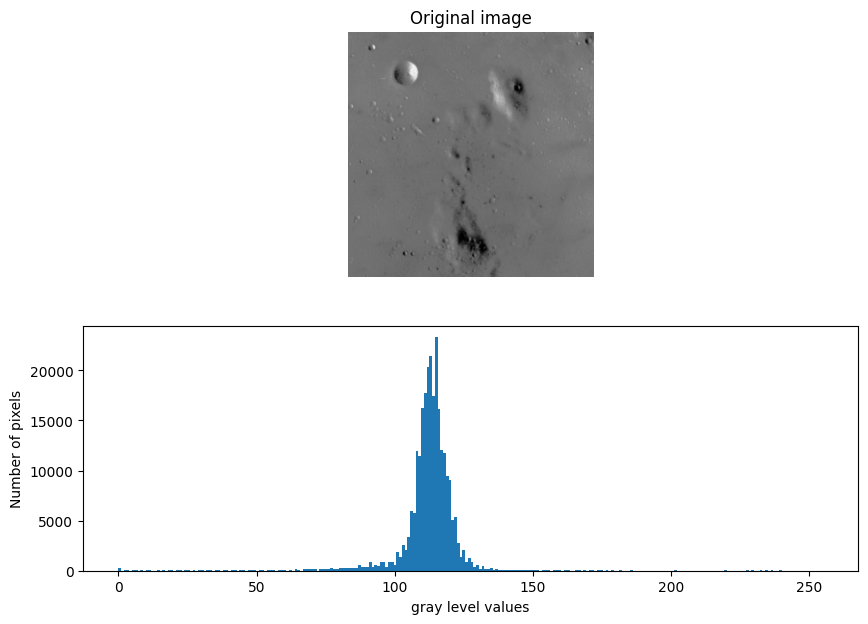

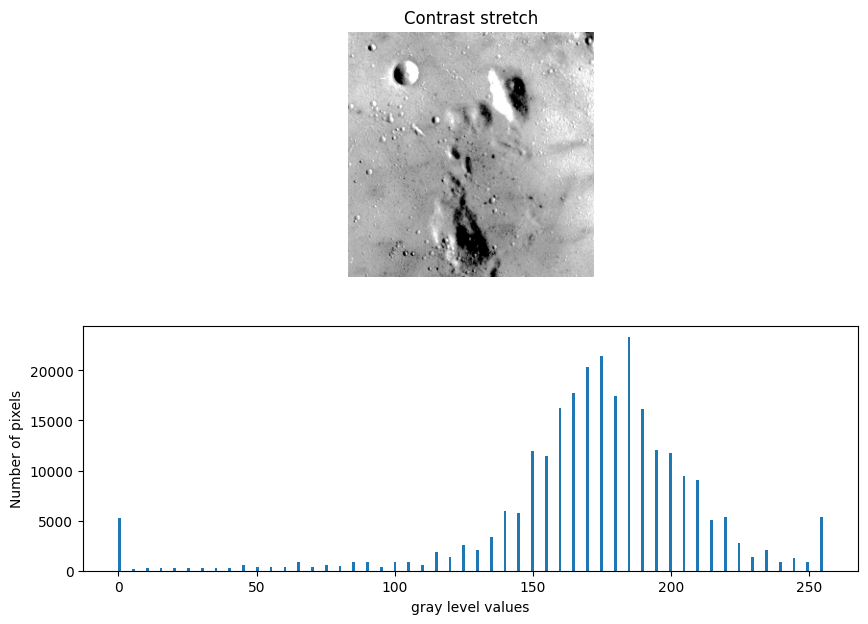

In [ ]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

In [ ]:
# Task#1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

# Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

# Task#3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


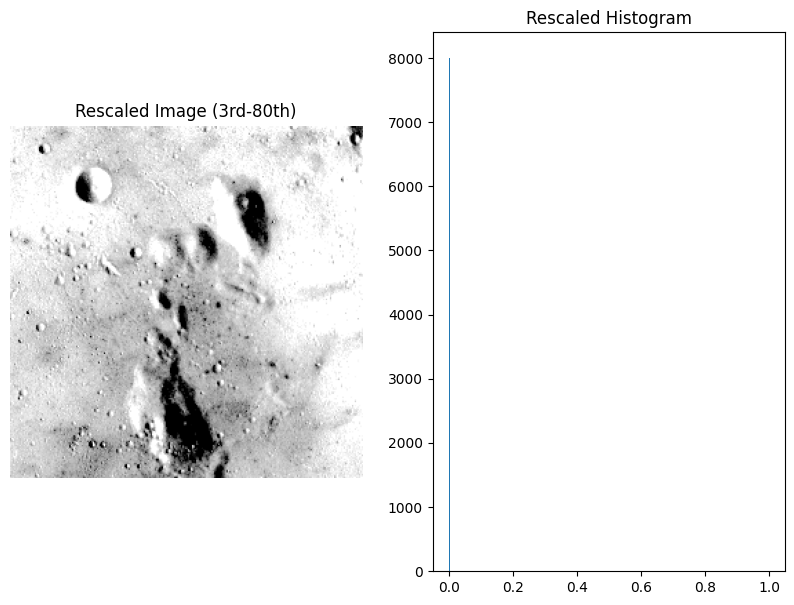

In [6]:
# Task #1: Rescale intensity values (3rd and 80th percentiles)
# Calculate the 3rd and 80th percentiles of the moon image
p3, p80 = np.percentile(img, (3, 80))

# Rescale the intensity to stretch the contrast
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

# Plotting the results
fig = plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
plt.imshow(img_rescale, cmap='gray')
plt.title('Rescaled Image (3rd-80th)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 1))
plt.title('Rescaled Histogram')
plt.show()


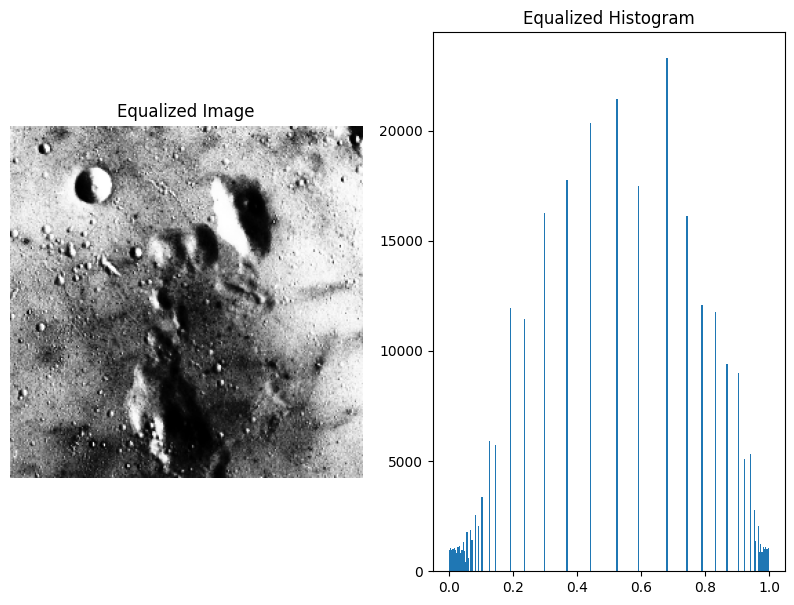

In [7]:
# Task #2: Histogram Equalization using equalize_hist function
img_eq = exposure.equalize_hist(img)

# Display the image and its flattened histogram
fig = plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
plt.imshow(img_eq, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.title('Equalized Histogram')
plt.show()

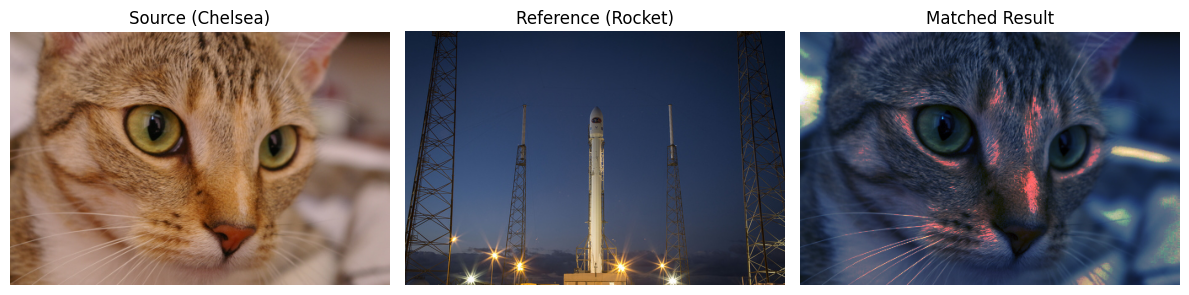

In [8]:
# Task #3: Histogram Matching using rocket (reference) and chelsea images
from skimage import data

# Load images from skimage data
source = data.chelsea()
reference = data.rocket()

# Apply histogram matching
# channel_axis=-1 is used for color images (RGB)
matched = exposure.match_histograms(source, reference, channel_axis=-1)

# Display the result
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

ax1.imshow(source)
ax1.set_title('Source (Chelsea)')
ax2.imshow(reference)
ax2.set_title('Reference (Rocket)')
ax3.imshow(matched)
ax3.set_title('Matched Result')

for ax in (ax1, ax2, ax3):
    ax.axis('off')
plt.tight_layout()
plt.show()
